In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print("✅ All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully
Pandas version: 2.2.2
NumPy version: 1.26.4


In [2]:
df = pd.read_csv('../data/creditcard.csv')

print(f"✅ Dataset loaded successfully")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Dataset size: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

✅ Dataset loaded successfully
Rows: 284,807
Columns: 31
Dataset size: 67.4 MB


# EDA

In [4]:
# print first 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# print datatypes of all columns
print("=== Data Types ===")
print(df.dtypes)
# total missing values
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== Data Types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== Missing Values ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
# check total legitimate and total fraud transactions
fraud_count = df['Class'].value_counts()
# calculates fruad rate
fraud_pct = df['Class'].mean() * 100

print("=== Class Distribution ===")
print(f"Legitimate transactions: {fraud_count[0]:,}")
print(f"Fraudulent transactions:  {fraud_count[1]:,}")
print(f"\nFraud rate: {fraud_pct:.4f}%")
print(f"Imbalance ratio: {fraud_count[0]//fraud_count[1]:,} legitimate for every 1 fraud")
print(f"\n⚠️  A dumb model predicting 'not fraud' always gets {100-fraud_pct:.2f}% accuracy — this is why accuracy is useless here")

=== Class Distribution ===
Legitimate transactions: 284,315
Fraudulent transactions:  492

Fraud rate: 0.1727%
Imbalance ratio: 577 legitimate for every 1 fraud

⚠️  A dumb model predicting 'not fraud' always gets 99.83% accuracy — this is why accuracy is useless here


In [7]:
# gives you 8 key statistics for every column in one line — count, mean, std, min, max, and percentiles
print("=== Statistical Summary ===")
df.describe().round(2)

=== Statistical Summary ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


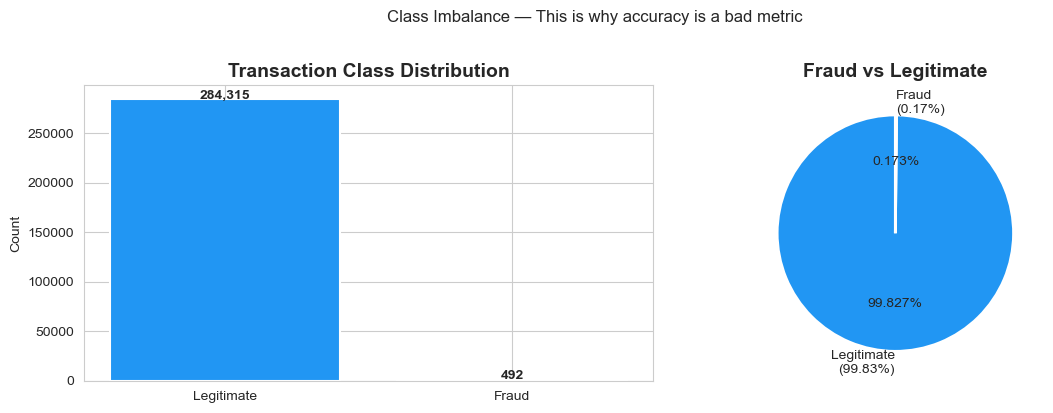

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Creates two charts side by side — a bar chart and a pie chart — both showing the class imbalance between fraud and legitimate transactions.
# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], 
            df['Class'].value_counts().values,
            color=['#2196F3', '#F44336'], 
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Class Distribution', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['Class'].value_counts().values):
    axes[0].text(i, v + 1000, f'{v:,}', 
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(df['Class'].value_counts().values,
            labels=['Legitimate\n(99.83%)', 'Fraud\n(0.17%)'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.3f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Fraud vs Legitimate', 
                   fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance — This is why accuracy is a bad metric',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

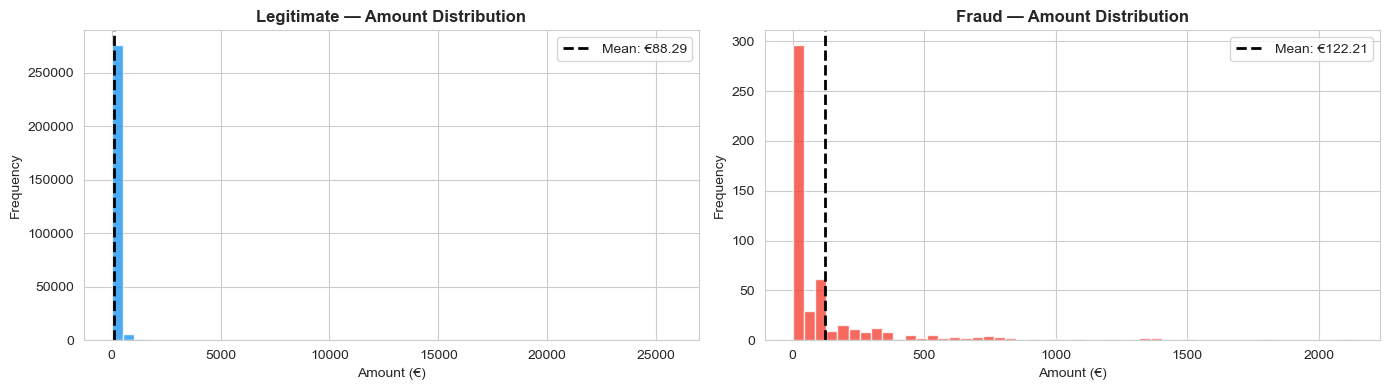

Legitimate avg amount: €88.29
Fraud avg amount:      €122.21

💡 Insight: Fraud transactions have lower average amounts
   Fraudsters keep amounts small to avoid triggering alerts


In [9]:
# 2 histograms side by side one for legitimate transactions, one for fraud transactions. Both showing Amount distribution.
# Both show — how many transactions happened at each amount level.
# Legitimate = mostly small purchases — people buying everyday things.
# Fraud = more random amounts — fraudsters don't follow normal spending patterns. Sometimes small, sometimes large, more unpredictable.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, (cls, label, color) in enumerate([(0, 'Legitimate', '#2196F3'), 
                                           (1, 'Fraud', '#F44336')]):
    subset = df[df['Class'] == cls]['Amount']
    axes[i].hist(subset, bins=50, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{label} — Amount Distribution', fontweight='bold')
    axes[i].set_xlabel('Amount (€)')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(subset.mean(), color='black', linestyle='--', 
                    linewidth=2, label=f'Mean: €{subset.mean():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

print(f"Legitimate avg amount: €{df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Fraud avg amount:      €{df[df['Class']==1]['Amount'].mean():.2f}")
print(f"\n💡 Insight: Fraud transactions have lower average amounts")
print(f"   Fraudsters keep amounts small to avoid triggering alerts")

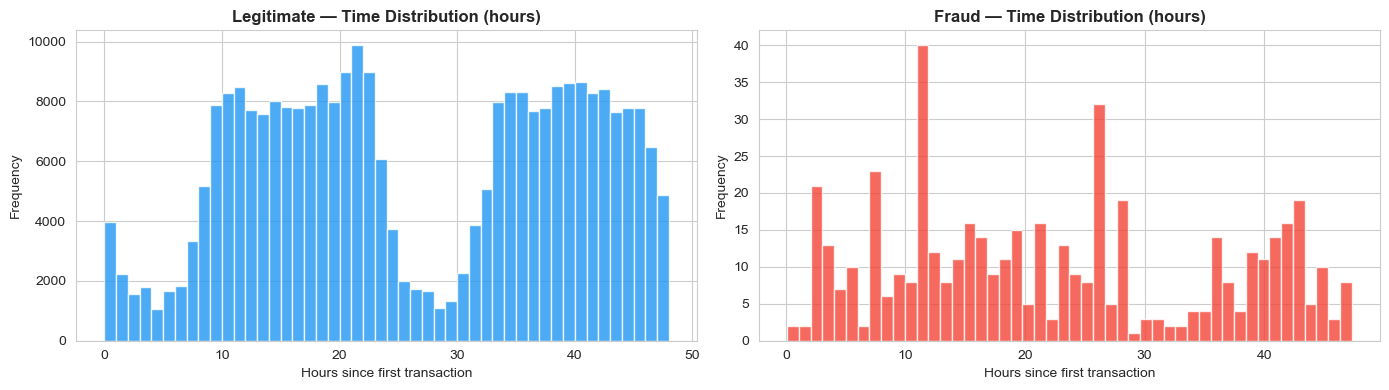

💡 Insight: Legitimate transactions dip at night (people sleep)
   Fraud transactions are more evenly spread — fraudsters work 24/7


In [10]:
# Left chart — when legitimate transactions happen (by hour)
# Right chart — when fraud transactions happen (by hour)
# Legitimate transactions:
# High activity → morning and afternoon
# Low activity  → night (people sleep)
# Pattern = rises and falls like human behaviour
# Fraud transactions:
# Activity is spread evenly across all hours
# Even at 3am — fraud is happening
# Pattern = flat, no dip at night

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, (cls, label, color) in enumerate([(0, 'Legitimate', '#2196F3'),
                                           (1, 'Fraud', '#F44336')]):
    subset = df[df['Class'] == cls]['Time'] / 3600  # convert to hours
    axes[i].hist(subset, bins=48, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{label} — Time Distribution (hours)', fontweight='bold')
    axes[i].set_xlabel('Hours since first transaction')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("💡 Insight: Legitimate transactions dip at night (people sleep)")
print("   Fraud transactions are more evenly spread — fraudsters work 24/7")

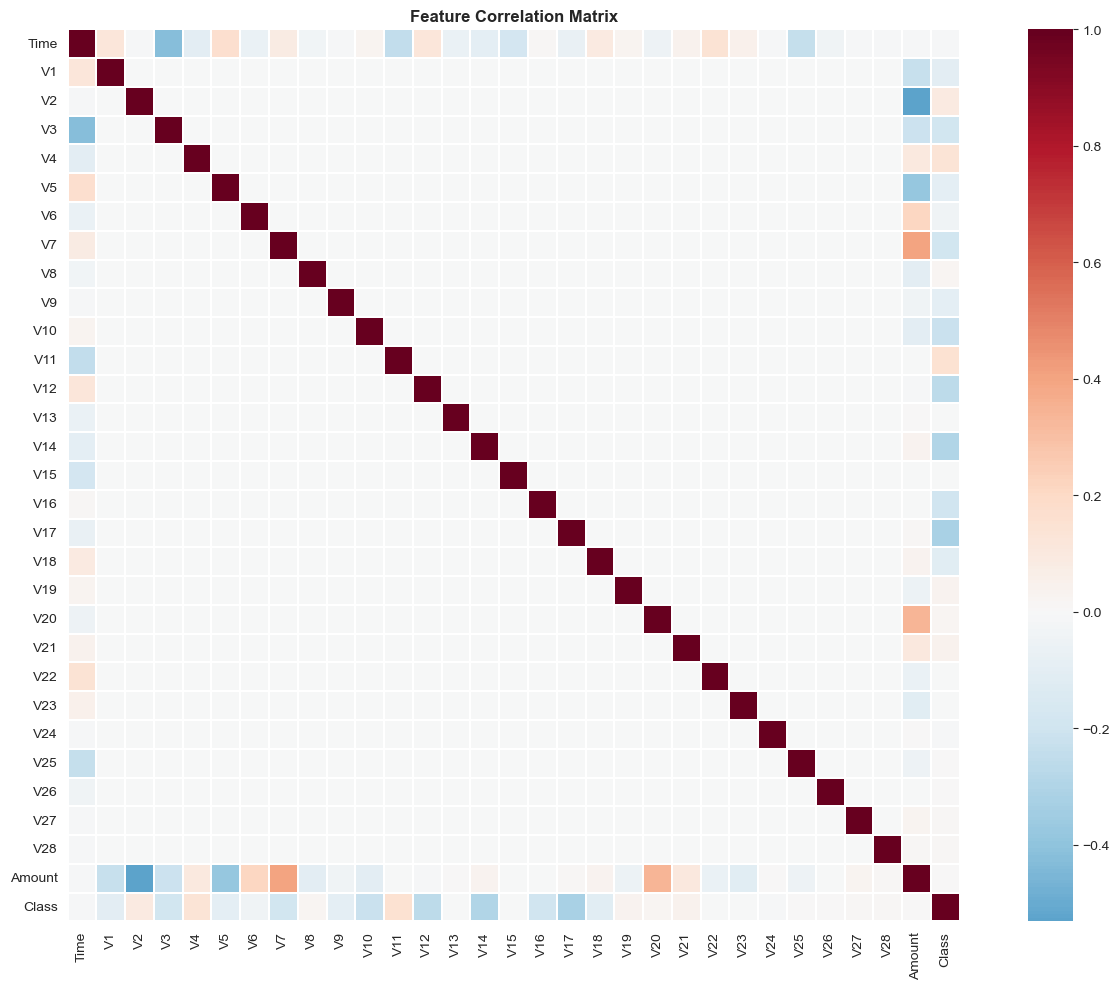

Top features correlated with fraud:
V17    0.326
V14    0.303
V12    0.261
V10    0.217
V16    0.197
V3     0.193
V7     0.187
V11    0.155
V4     0.133
V18    0.111
Name: Class, dtype: float64


In [11]:
# heatmap 
# 
# 1. What chart/output it makes:
# Correlation heatmap + top 10 features most related to fraud
# 2. What it shows:
# V17 and V14 are most correlated with fraud
# 3. Why you made it:
# To find which features are most important before building the model
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3, square=True)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print("Top features correlated with fraud:")
print(corr['Class'].drop('Class').abs().sort_values(ascending=False).head(10).round(3))

# Feature engineering

In [13]:
# Create new features from Time
df['hour'] = (df['Time'] // 3600) % 24
df['is_night'] = ((df['hour'] < 6) | (df['hour'] >= 22)).astype(int)

# Scale Amount (V1-V28 already scaled via PCA, Amount is raw)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Drop original unscaled columns
df_model = df.drop(columns=['Time', 'Amount'])

print("✅ Feature engineering complete")
print(f"New features added: 'hour', 'is_night', 'Amount_scaled'")
print(f"Dropped: 'Time', 'Amount' (replaced by scaled version)")
print(f"\nFinal dataset shape: {df_model.shape}")
print(f"Columns: {list(df_model.columns)}")

✅ Feature engineering complete
New features added: 'hour', 'is_night', 'Amount_scaled'
Dropped: 'Time', 'Amount' (replaced by scaled version)

Final dataset shape: (284807, 32)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'hour', 'is_night', 'Amount_scaled']


In [14]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Class', axis=1)
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps same fraud ratio in both splits
)

print("✅ Train/Test split complete")
print(f"\nTraining set:   {X_train.shape[0]:,} rows")
print(f"Test set:       {X_test.shape[0]:,} rows")
print(f"\nTrain fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.4f}%")
print(f"\n✅ Both splits have same fraud rate — stratify=y worked correctly")

✅ Train/Test split complete

Training set:   227,845 rows
Test set:       56,962 rows

Train fraud rate: 0.1729%
Test fraud rate:  0.1720%

✅ Both splits have same fraud rate — stratify=y worked correctly


In [15]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("✅ SMOTE applied on training data only")
print(f"\nBefore SMOTE:")
print(f"  Legitimate: {(y_train==0).sum():,}")
print(f"  Fraud:      {(y_train==1).sum():,}")
print(f"\nAfter SMOTE:")
print(f"  Legitimate: {(y_train_res==0).sum():,}")
print(f"  Fraud:      {(y_train_res==1).sum():,}")
print(f"\n⚠️  SMOTE applied to TRAINING data only")
print(f"   Test set stays untouched — reflects real world distribution")

✅ SMOTE applied on training data only

Before SMOTE:
  Legitimate: 227,451
  Fraud:      394

After SMOTE:
  Legitimate: 227,451
  Fraud:      227,451

⚠️  SMOTE applied to TRAINING data only
   Test set stays untouched — reflects real world distribution


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

y_pred_lr  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("✅ Logistic Regression trained\n")
print("=== Results ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Legitimate', 'Fraud']))

Training Logistic Regression...
✅ Logistic Regression trained

=== Results ===
AUC-ROC: 0.9721
F1 Score: 0.1020

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [17]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (takes ~1 min)...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained\n")
print("=== Results ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Legitimate', 'Fraud']))

Training Random Forest (takes ~1 min)...
✅ Random Forest trained

=== Results ===
AUC-ROC: 0.9836
F1 Score: 0.5139

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.37      0.85      0.51        98

    accuracy                           1.00     56962
   macro avg       0.68      0.92      0.76     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
from xgboost import XGBClassifier

print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_res, y_train_res)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("✅ XGBoost trained\n")
print("=== Results ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Legitimate', 'Fraud']))

Training XGBoost...
✅ XGBoost trained

=== Results ===
AUC-ROC: 0.9819
F1 Score: 0.6391

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.51      0.87      0.64        98

    accuracy                           1.00     56962
   macro avg       0.75      0.93      0.82     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree...")
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train_res, y_train_res)

y_pred_dt  = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("✅ Decision Tree trained\n")
print("=== Results ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_dt):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=['Legitimate', 'Fraud']))

Training Decision Tree...
✅ Decision Tree trained

=== Results ===
AUC-ROC: 0.8869
F1 Score: 0.1202

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.84      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [20]:
from sklearn.metrics import precision_score, recall_score

models_summary = {
    'Logistic Regression': (y_pred_lr,  y_proba_lr),
    'Decision Tree':       (y_pred_dt,  y_proba_dt),
    'Random Forest':       (y_pred_rf,  y_proba_rf),
    'XGBoost':             (y_pred_xgb, y_proba_xgb),
}

print("=" * 65)
print(f"{'Model':<22} {'AUC-ROC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("=" * 65)

for name, (pred, proba) in models_summary.items():
    auc  = roc_auc_score(y_test, proba)
    f1   = f1_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred)
    marker = " ⭐" if name == "XGBoost" else ""
    print(f"{name:<22} {auc:>8.4f} {f1:>8.4f} {prec:>10.4f} {rec:>8.4f}{marker}")

print("=" * 65)
print("\n🏆 XGBoost wins — highest AUC-ROC and best overall balance")
print("💡 Logistic Regression has high recall but terrible precision")
print("   — it flags almost everything as fraud (too many false alarms)")

Model                   AUC-ROC       F1  Precision   Recall
Logistic Regression      0.9721   0.1020     0.0540   0.9082
Decision Tree            0.8869   0.1202     0.0648   0.8367
Random Forest            0.9836   0.5139     0.3689   0.8469
XGBoost                  0.9819   0.6391     0.5060   0.8673 ⭐

🏆 XGBoost wins — highest AUC-ROC and best overall balance
💡 Logistic Regression has high recall but terrible precision
   — it flags almost everything as fraud (too many false alarms)


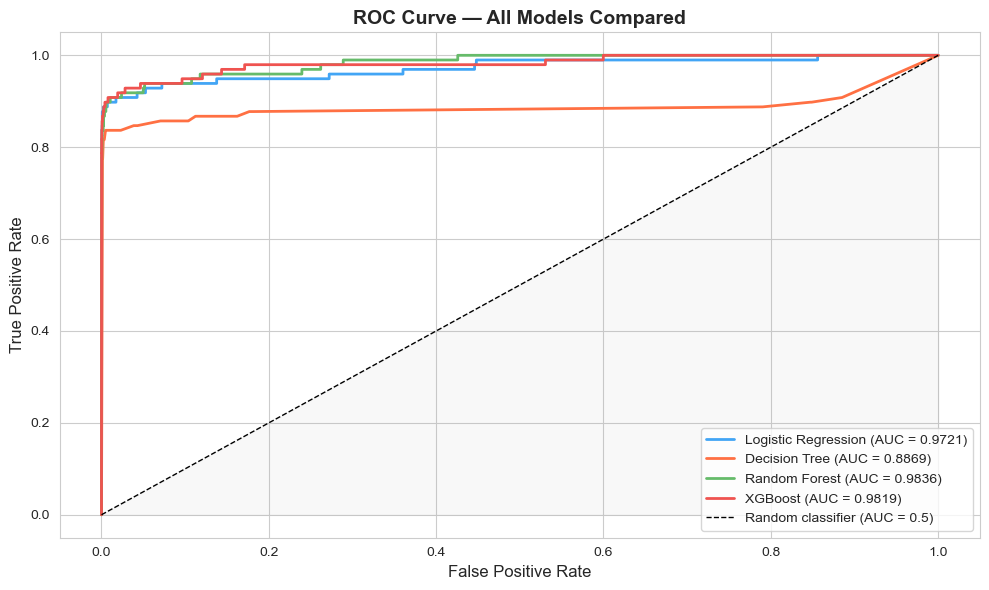

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

colors = ['#42A5F5', '#FF7043', '#66BB6A', '#EF5350']
model_names = ['Logistic Regression', 'Decision Tree', 
               'Random Forest', 'XGBoost']
probas = [y_proba_lr, y_proba_dt, y_proba_rf, y_proba_xgb]

for name, proba, color in zip(model_names, probas, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models Compared', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

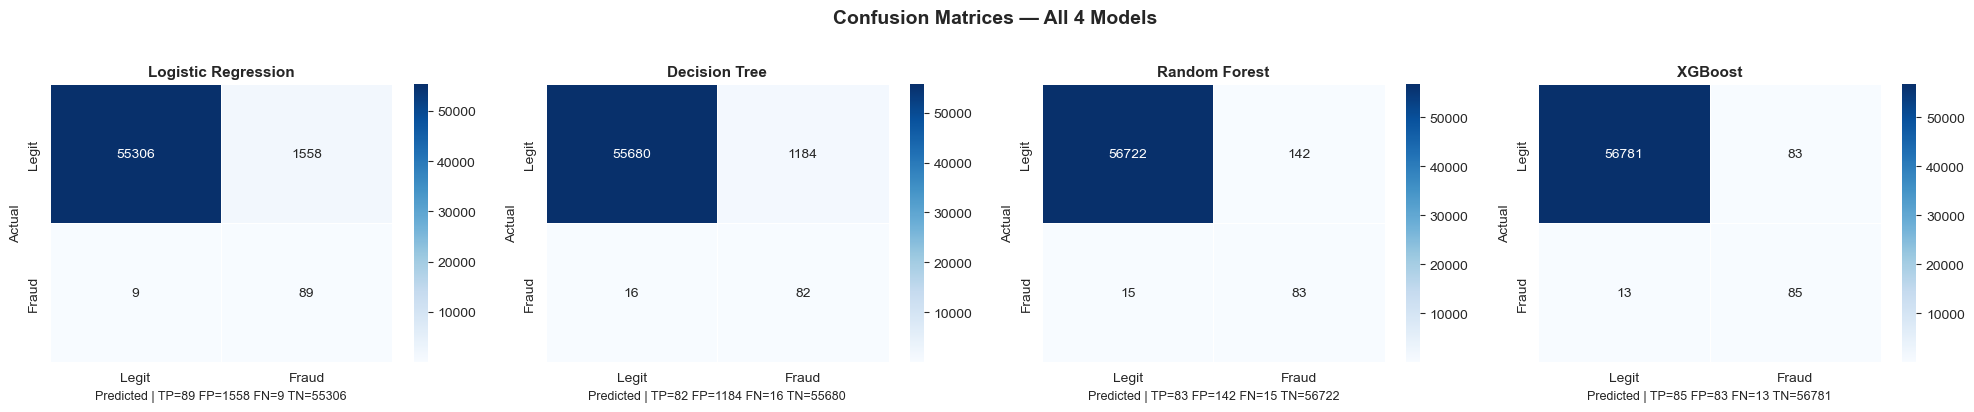

How to read:
  TP = fraud correctly caught
  FN = fraud missed — most costly
  FP = legit flagged as fraud — false alarm
  TN = legit correctly passed


In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'],
                linewidths=0.5)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_ylabel('Actual')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted | TP={tp} FP={fp} FN={fn} TN={tn}', fontsize=9)

plt.suptitle('Confusion Matrices — All 4 Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("How to read:")
print("  TP = fraud correctly caught")
print("  FN = fraud missed — most costly")
print("  FP = legit flagged as fraud — false alarm")
print("  TN = legit correctly passed")

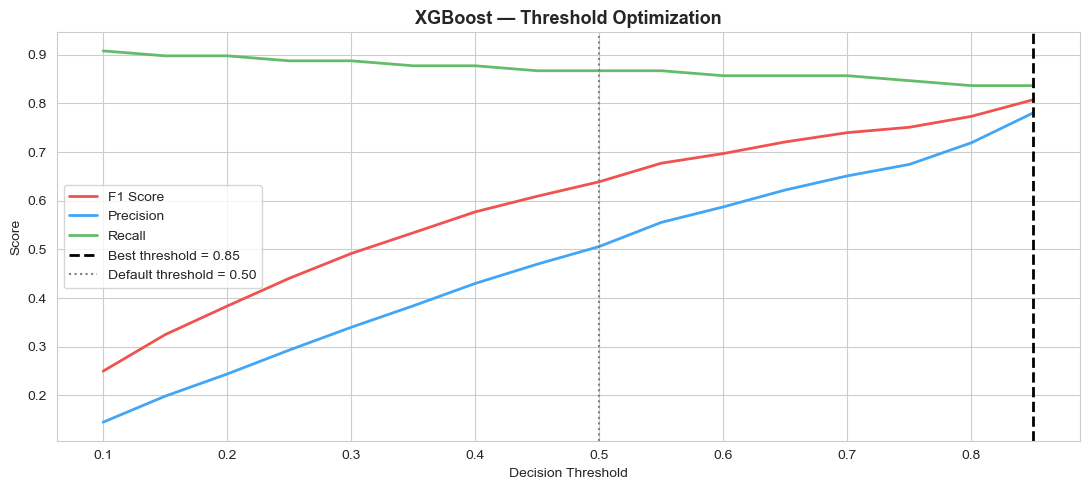

Default threshold (0.50):
  F1=0.6391  Precision=0.5060  Recall=0.8673

Optimal threshold (0.85):
  F1=0.8079  Precision=0.7810  Recall=0.8367

💡 Lowering threshold increases recall (catch more fraud)
   at the cost of precision (more false alarms)
   This is a BUSINESS decision, not just a model decision


In [23]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.05)
f1s, precs, recs = [], [], []

for t in thresholds:
    pred_t = (y_proba_xgb >= t).astype(int)
    f1s.append(f1_score(y_test, pred_t, zero_division=0))
    precs.append(precision_score(y_test, pred_t, zero_division=0))
    recs.append(recall_score(y_test, pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]

plt.figure(figsize=(11, 5))
plt.plot(thresholds, f1s,   label='F1 Score',  color='#EF5350', lw=2)
plt.plot(thresholds, precs, label='Precision',  color='#42A5F5', lw=2)
plt.plot(thresholds, recs,  label='Recall',     color='#66BB6A', lw=2)
plt.axvline(best_t, color='black', linestyle='--', lw=2,
            label=f'Best threshold = {best_t:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', lw=1.5,
            label='Default threshold = 0.50')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('XGBoost — Threshold Optimization', fontweight='bold', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

# Apply best threshold
y_pred_tuned = (y_proba_xgb >= best_t).astype(int)
print(f"Default threshold (0.50):")
print(f"  F1={f1_score(y_test, y_pred_xgb):.4f}  Precision={precision_score(y_test, y_pred_xgb):.4f}  Recall={recall_score(y_test, y_pred_xgb):.4f}")
print(f"\nOptimal threshold ({best_t:.2f}):")
print(f"  F1={f1_score(y_test, y_pred_tuned):.4f}  Precision={precision_score(y_test, y_pred_tuned):.4f}  Recall={recall_score(y_test, y_pred_tuned):.4f}")
print(f"\n💡 Lowering threshold increases recall (catch more fraud)")
print(f"   at the cost of precision (more false alarms)")
print(f"   This is a BUSINESS decision, not just a model decision")

Computing SHAP values (takes ~1 min)...
✅ SHAP values computed



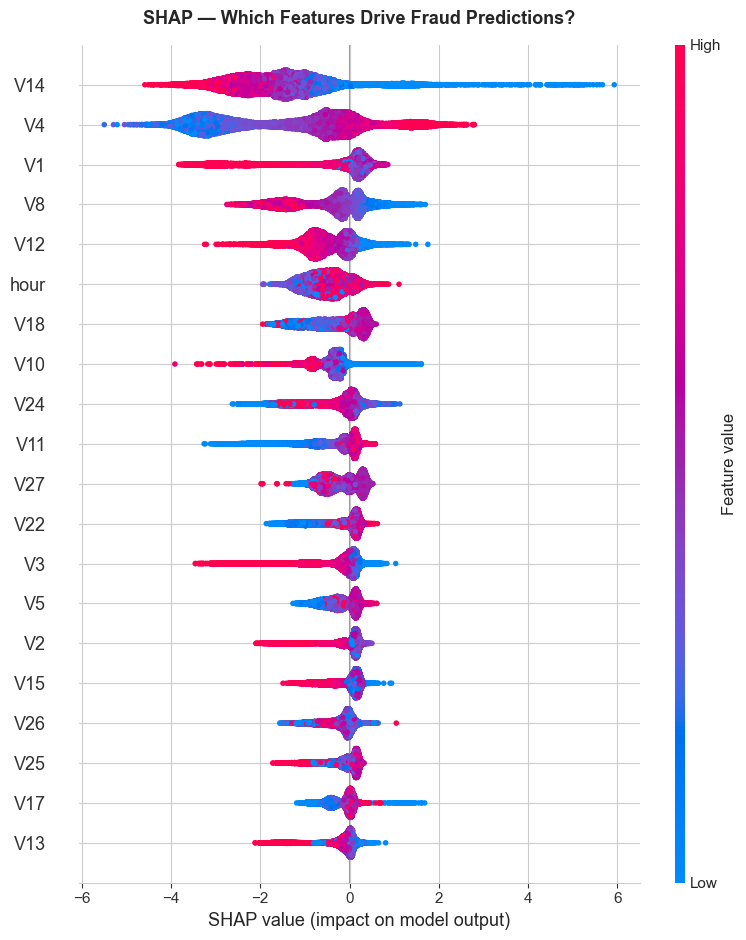

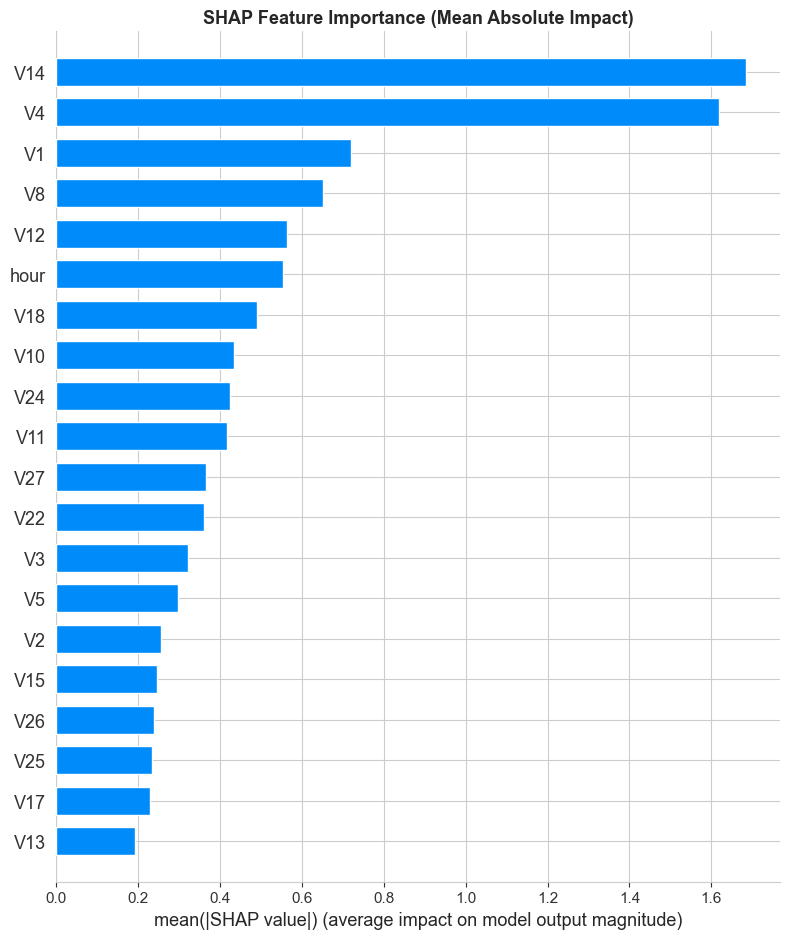

How to read the summary plot:
  Each dot = one transaction
  Red = high feature value | Blue = low feature value
  Right of 0 = pushed prediction toward FRAUD
  Left of 0  = pushed prediction toward LEGITIMATE


In [24]:
import shap

print("Computing SHAP values (takes ~1 min)...")
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values computed\n")

# Summary plot — most important visual in the whole notebook
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP — Which Features Drive Fraud Predictions?',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Bar plot — clean ranking
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance (Mean Absolute Impact)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("How to read the summary plot:")
print("  Each dot = one transaction")
print("  Red = high feature value | Blue = low feature value")
print("  Right of 0 = pushed prediction toward FRAUD")
print("  Left of 0  = pushed prediction toward LEGITIMATE")

Explaining a FRAUD transaction:
  Test index:           840
  Fraud probability:    0.9999
  Actual label:         1 (1 = Fraud)
  Predicted correctly:  True


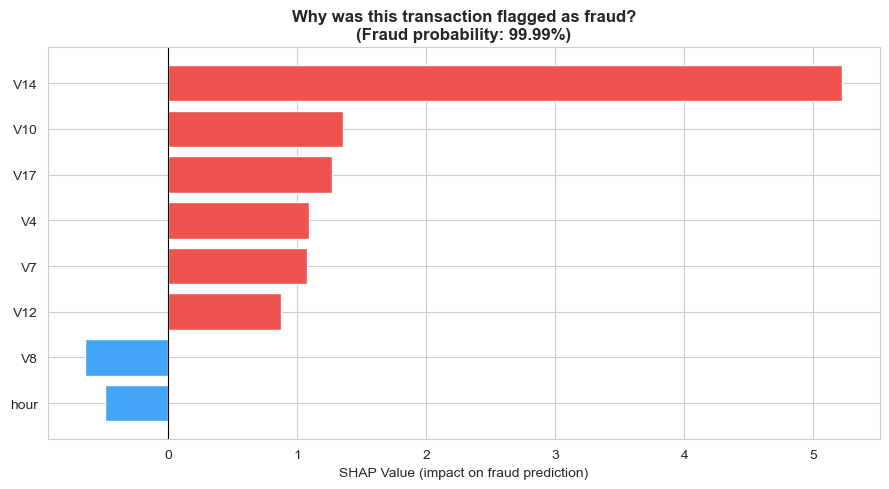


Red bars = feature pushed prediction TOWARD fraud
Blue bars = feature pushed prediction AWAY from fraud


In [25]:
# Pick one fraud transaction and explain exactly why it was flagged
fraud_indices = np.where(y_test.values == 1)[0]
fraud_idx = fraud_indices[0]

print(f"Explaining a FRAUD transaction:")
print(f"  Test index:           {fraud_idx}")
print(f"  Fraud probability:    {y_proba_xgb[fraud_idx]:.4f}")
print(f"  Actual label:         {y_test.values[fraud_idx]} (1 = Fraud)")
print(f"  Predicted correctly:  {y_pred_xgb[fraud_idx] == y_test.values[fraud_idx]}")

# Show top features that caused this fraud flag
feature_names = X.columns.tolist()
shap_for_txn  = shap_values[fraud_idx]

top_features = sorted(
    zip(feature_names, shap_for_txn),
    key=lambda x: abs(x[1]),
    reverse=True
)[:8]

plt.figure(figsize=(9, 5))
names_top = [f[0] for f in top_features]
vals_top  = [f[1] for f in top_features]
colors    = ['#EF5350' if v > 0 else '#42A5F5' for v in vals_top]

plt.barh(names_top[::-1], vals_top[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('SHAP Value (impact on fraud prediction)')
plt.title(f'Why was this transaction flagged as fraud?\n(Fraud probability: {y_proba_xgb[fraud_idx]:.2%})',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("\nRed bars = feature pushed prediction TOWARD fraud")
print("Blue bars = feature pushed prediction AWAY from fraud")

In [26]:
import joblib
import os

os.makedirs('../model', exist_ok=True)

joblib.dump(xgb,      '../model/fraud_model.pkl')
joblib.dump(scaler,   '../model/scaler.pkl')
joblib.dump(explainer,'../model/shap_explainer.pkl')

print("✅ Model artifacts saved:")
print(f"  ../model/fraud_model.pkl     — trained XGBoost model")
print(f"  ../model/scaler.pkl          — StandardScaler")
print(f"  ../model/shap_explainer.pkl  — SHAP explainer")

# Verify by reloading
model_check = joblib.load('../model/fraud_model.pkl')
test_proba  = model_check.predict_proba(X_test[:3])[:, 1]
print(f"\n✅ Reload test passed — sample predictions: {test_proba.round(4)}")
print(f"\n🎉 NOTEBOOK COMPLETE — model is saved and ready for API")

✅ Model artifacts saved:
  ../model/fraud_model.pkl     — trained XGBoost model
  ../model/scaler.pkl          — StandardScaler
  ../model/shap_explainer.pkl  — SHAP explainer

✅ Reload test passed — sample predictions: [1.e-04 0.e+00 2.e-04]

🎉 NOTEBOOK COMPLETE — model is saved and ready for API
